# 09 - Interpretability: Which Sensors and Features Carry the Signal, and Which Drift?

**Goal:** open the "black box". The 128 features are 16 sensors x 8 feature types; we ask
1. which **sensors** and which **feature types** does a trained model actually rely on?
2. which of them can we **remove** without losing accuracy (and which are essential)?
3. which features **drift** most, and can a **drift-aware feature subset** do better than using everything?

> **Beginner note - permutation importance.** To find out how much a model relies on some features, shuffle those features' values among the samples of a
> test batch (this breaks their link to the gas label) and see how much the score drops. A big drop means the model needed those features.
> Features are highly redundant here (average correlation 0.77 between sensors), so we shuffle **whole groups together** (all 8 features of a sensor,
> or one feature type across all 16 sensors) rather than single features.
>
> **Two rules that keep this honest**
> * Permutation importance *analyses a fitted model* and uses test labels for scoring. It is **never** used to choose features that are then tested on the same batches.
> * **Feature selection uses batches 1-3 only.** For every feature we compute (a) how well it separates the gases (ANOVA F-statistic) and (b) how far each gas's median moves
>   from batch 1 to batches 2 and 3 (drift, in robust standard deviations). The rules and the fraction kept (**50%**) were declared before running; 25% and 75% are sensitivity checks.
>   The chosen features are then tested on batches 4-10 and compared with **50 random subsets** of the same size.

The three feature groupings: `type` (8 groups of 16 features), `sensor` (16 groups of 8) and `family` (steady-state `DR`/`|DR|`, rising EMAs, decaying EMAs).
Models: default SVM and Random Forest, scaling only, trained on batches 1-3 (protocol P1).

In [1]:
import os, sys, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "16"); warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.data import FEATURE_TYPES
from src.plotting import apply_style, INK, INK2, GRID, SERIES, MARKERS, SEQ, DIV
apply_style()
FIG = ROOT / "results" / "figures"; RES = ROOT / "results"
perm = pd.read_csv(RES / "09_perm_importance.csv"); abl = pd.read_csv(RES / "09_ablation_results.csv")
sel = pd.read_csv(RES / "09_selection_results.csv"); fs = pd.read_csv(RES / "09_feature_scores.csv")
b4 = pd.read_csv(RES / "04_baselines_results.csv")
print("permutation rows:", len(perm), "| ablation rows:", len(abl), "| selection rows:", len(sel), "| features scored:", len(fs))
ref = b4[(b4.model == "SVM") & (b4.variant == "raw") & (b4.protocol == "P1")].sort_values("test_batch").macro_f1.to_numpy()
allrows = abl[(abl.subset_kind == "all") & (abl.model == "SVM") & (abl.protocol == "P1")].sort_values("test_batch").macro_f1.to_numpy()
print(f"sanity check: 'all 128 features' SVM P1 equals the default SVM of notebook 04 (max difference {np.abs(ref - allrows).max():.1e})")

permutation rows: 378 | ablation rows: 1196 | selection rows: 3360 | features scored: 128
sanity check: 'all 128 features' SVM P1 equals the default SVM of notebook 04 (max difference 0.0e+00)


## 1. Which features carry the gas signal, and which drift? (training batches 1-3 only)

For every feature: discriminability **F** (higher = separates the gases better) and **drift** (how far each gas's median moves from batch 1 to batches 2-3, in robust standard deviations).
Group values are averages over the group's features (F on a log scale, because it is heavy-tailed).

,mean_logF,median_F,mean_drift
type,,,
DR,2.43,172.41,1.21
|DR|,1.97,348.97,1.35
EMA_inc_0.001,2.53,260.52,1.16
EMA_inc_0.01,2.63,498.66,1.27
EMA_inc_0.1,2.22,367.67,1.30
EMA_dec_0.001,2.44,216.98,1.12
EMA_dec_0.01,2.29,189.15,1.05
EMA_dec_0.1,1.84,83.99,0.95


,mean_logF,median_F,mean_drift
sensor,,,
S01,2.91,1206.29,1.77
S02,3.03,1451.55,1.49
S03,2.12,178.79,0.66
S04,1.73,118.44,0.72
S05,1.65,75.73,1.19
S06,1.54,65.92,1.14
S07,2.06,193.11,0.79
S08,2.05,193.25,0.84
S09,3.02,1042.90,2.24


correlation between a feature's discriminability and its drift: +0.39


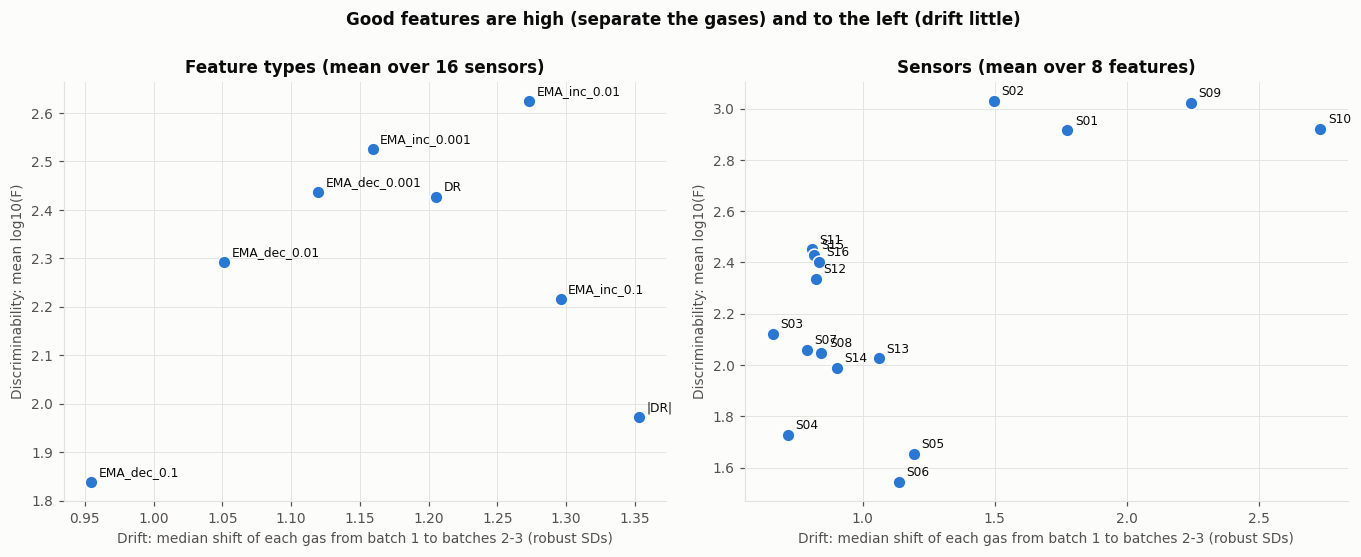

In [2]:
fs["logF"] = np.log10(fs.F + 1e-9)
bytype = fs.groupby("type", sort=False).agg(mean_logF=("logF", "mean"), median_F=("F", "median"), mean_drift=("drift", "mean")).loc[FEATURE_TYPES]
bysensor = fs.groupby("sensor", sort=False).agg(mean_logF=("logF", "mean"), median_F=("F", "median"), mean_drift=("drift", "mean"))
bytype.to_csv(RES / "09_scores_by_type.csv"); bysensor.to_csv(RES / "09_scores_by_sensor.csv")
display(bytype.round(2)); display(bysensor.round(2))
print(f"correlation between a feature's discriminability and its drift: {np.corrcoef(fs.logF, fs.drift)[0, 1]:+.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), sharey=False)
for ax, (title, df) in zip(axes, [("Feature types (mean over 16 sensors)", bytype), ("Sensors (mean over 8 features)", bysensor)]):
    ax.scatter(df.mean_drift, df.mean_logF, s=70, color=SERIES[0], edgecolor="white", zorder=3)
    for name, r in df.iterrows(): ax.annotate(name, (r.mean_drift, r.mean_logF), textcoords="offset points", xytext=(5, 4), fontsize=8)
    ax.set_xlabel("Drift: median shift of each gas from batch 1 to batches 2-3 (robust SDs)"); ax.set_ylabel("Discriminability: mean log10(F)"); ax.set_title(title)
fig.suptitle("Good features are high (separate the gases) and to the left (drift little)", y=1.0, fontsize=11, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "33_discriminability_vs_drift.png"); plt.show()

## 2. What does a trained model rely on? (permutation importance)

Mean drop in macro-F1 on test batches 4-10 when a group of features is shuffled together (10 repetitions per batch). Larger drop = the model relies on that group more.

Feature families:


model,Random Forest,SVM
group,,
decaying EMA,0.138,0.172
rising EMA,0.094,0.301
"steady-state (DR, |DR|)",0.096,0.199


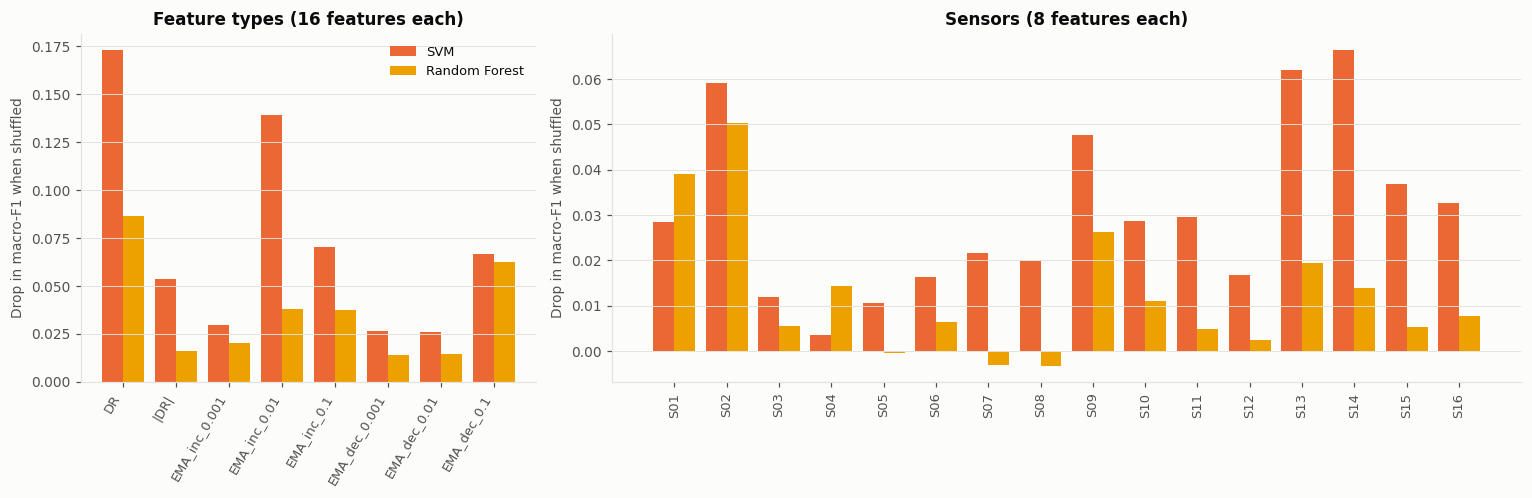

By feature type, near vs far test batches:


near B4-5            far B8-10       
model         Random Forest    SVM Random Forest    SVM
group                                                  
DR                    0.087  0.123         0.092  0.224
|DR|                  0.028  0.053        -0.030  0.047
EMA_inc_0.001         0.005  0.034         0.041  0.031
EMA_inc_0.01          0.005  0.249         0.048  0.070
EMA_inc_0.1           0.010  0.113         0.036  0.034
EMA_dec_0.001         0.027  0.019         0.010  0.042
EMA_dec_0.01          0.004  0.038         0.020  0.028
EMA_dec_0.1           0.067  0.144         0.055  0.029

In [3]:
def agg(kind, batches=range(4, 11)):
    d = perm[(perm.group_kind == kind) & perm.test_batch.isin(list(batches))]
    return d.groupby(["group", "model"]).importance_mean.mean().unstack("model")
imp_type, imp_sensor, imp_family = agg("type").loc[FEATURE_TYPES], agg("sensor"), agg("family")
imp_type.to_csv(RES / "09_perm_importance_by_type.csv"); imp_sensor.to_csv(RES / "09_perm_importance_by_sensor.csv"); imp_family.to_csv(RES / "09_perm_importance_by_family.csv")
print("Feature families:"); display(imp_family.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [8, 16]})
for ax, (title, df) in zip(axes, [("Feature types (16 features each)", imp_type), ("Sensors (8 features each)", imp_sensor)]):
    x = np.arange(len(df)); w = 0.4
    ax.bar(x - w / 2, df["SVM"], w, color=SERIES[1], label="SVM"); ax.bar(x + w / 2, df["Random Forest"], w, color=SERIES[3], label="Random Forest")
    ax.set_xticks(x); ax.set_xticklabels(df.index, rotation=60 if len(df) < 10 else 90, ha="right" if len(df) < 10 else "center", fontsize=8.5); ax.grid(axis="x", visible=False)
    ax.set_ylabel("Drop in macro-F1 when shuffled"); ax.set_title(title)
axes[0].legend(frameon=False, fontsize=8.5); fig.tight_layout(); fig.savefig(FIG / "34_permutation_importance.png"); plt.show()

near, far = agg("type", [4, 5]), agg("type", [8, 9, 10])
nf = pd.concat({"near B4-5": near, "far B8-10": far}, axis=1).loc[FEATURE_TYPES]; nf.to_csv(RES / "09_perm_importance_near_far.csv"); print("By feature type, near vs far test batches:"); display(nf.round(3))

## 3. Retraining on feature subsets (ablation)

Instead of shuffling, retrain the SVM on a subset: **only** one group, or **everything except** one group. Dashed line = all 128 features.

SVM P1 with all 128 features: macro-F1 0.690


,only type,leave out type
subset,,
DR,0.611,0.655
|DR|,0.472,0.678
EMA_inc_0.001,0.573,0.685
EMA_inc_0.01,0.485,0.675
EMA_inc_0.1,0.496,0.672
EMA_dec_0.001,0.579,0.688
EMA_dec_0.01,0.540,0.691
EMA_dec_0.1,0.413,0.664


,only family
subset,
decaying EMA,0.562
rising EMA,0.619
"steady-state (DR, |DR|)",0.584


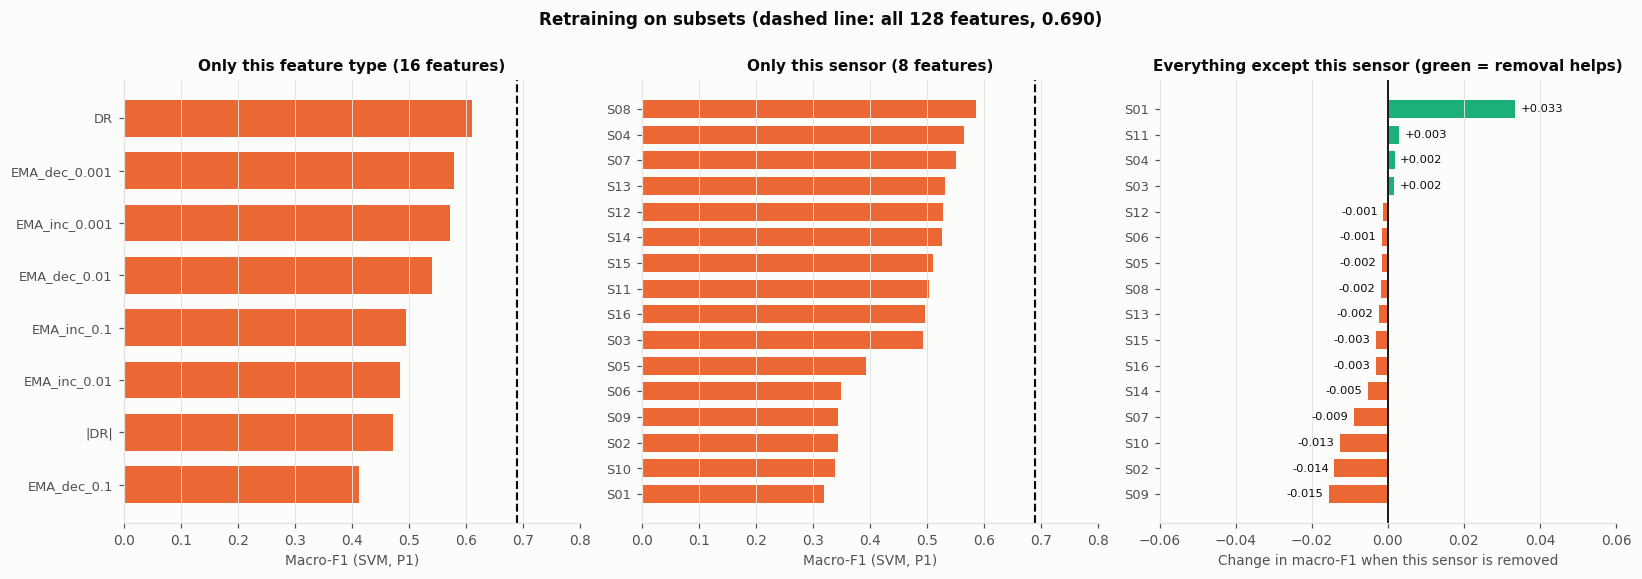

In [4]:
def ab(kind, model="SVM", proto="P1"):
    d = abl[(abl.subset_kind == kind) & (abl.model == model) & (abl.protocol == proto)]
    return d.groupby("subset").macro_f1.mean()
all_f1 = ab("all").iloc[0]; print(f"SVM P1 with all 128 features: macro-F1 {all_f1:.3f}")
only_type, only_family, only_sensor = ab("only type").loc[FEATURE_TYPES], ab("only family"), ab("only sensor")
out_type, out_sensor = ab("leave out type").loc[FEATURE_TYPES], ab("leave out sensor")
tab = pd.concat({"only type": only_type, "leave out type": out_type}, axis=1); tab.to_csv(RES / "09_ablation_by_type_SVM_P1.csv"); display(tab.round(3))
display(pd.concat({"only family": only_family}, axis=1).round(3))
sens = pd.concat({"only sensor": only_sensor, "leave out sensor": out_sensor}, axis=1); sens.to_csv(RES / "09_ablation_by_sensor_SVM_P1.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, (title, s) in zip(axes[:2], [("Only this feature type (16 features)", only_type), ("Only this sensor (8 features)", only_sensor)]):
    s = s.sort_values(); ax.barh(range(len(s)), s.values, color=SERIES[1], height=0.7)
    ax.axvline(all_f1, color=INK, ls="--", lw=1.4); ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=8.5); ax.grid(axis="y", visible=False)
    ax.set_xlabel("Macro-F1 (SVM, P1)"); ax.set_title(title, fontsize=10); ax.set_xlim(0, 0.8)
ax = axes[2]; d = (out_sensor - all_f1).sort_values()
ax.barh(range(len(d)), d.values, color=[SERIES[2] if v > 0 else SERIES[1] for v in d.values], height=0.7)
for i, v in enumerate(d.values): ax.text(v + (0.0015 if v >= 0 else -0.0015), i, f"{v:+.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=7.5)
ax.axvline(0, color=INK, lw=1.2); ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=8.5); ax.grid(axis="y", visible=False)
ax.set_xlim(-0.06, 0.06); ax.set_xlabel("Change in macro-F1 when this sensor is removed"); ax.set_title("Everything except this sensor (green = removal helps)", fontsize=10)
fig.suptitle(f"Retraining on subsets (dashed line: all 128 features, {all_f1:.3f})", y=1.0, fontsize=11, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "35_feature_subset_ablation.png"); plt.show()

## 4. A drift-aware feature subset? (selection from batches 1-3 only)

Rules (declared in advance, fraction kept = 50%): **stable** = the half with the lowest drift; **discriminative** = the half with the highest F;
**balanced** = the half with the highest `F / (1 + drift)`. They are compared with using **all** features and with **50 random subsets** of the same size.
All models are default-setting, scaling only, trained on batches 1-3 and tested on 4-10.

,model,fraction kept,all features,random mean,random 5-95%,stable,stable beats x% of random,discriminative,discriminative beats x% of random,balanced,balanced beats x% of random
0,SVM,0.25,0.690,0.653,0.598-0.706,0.550,0.0,0.514,0.0,0.493,0.0
1,SVM,0.50,0.690,0.678,0.651-0.697,0.683,56.0,0.584,0.0,0.565,0.0
2,SVM,0.75,0.690,0.683,0.669-0.695,0.683,54.0,0.680,36.0,0.682,48.0
3,Random Forest,0.25,0.518,0.497,0.437-0.558,0.563,96.0,0.465,16.0,0.460,12.0
4,Random Forest,0.50,0.518,0.521,0.464-0.577,0.639,100.0,0.456,2.0,0.473,10.0
5,Random Forest,0.75,0.518,0.514,0.467-0.554,0.588,100.0,0.520,58.0,0.539,84.0
6,kNN,0.25,0.609,0.586,0.529-0.636,0.492,0.0,0.515,2.0,0.505,0.0
7,kNN,0.50,0.609,0.607,0.574-0.640,0.593,28.0,0.580,14.0,0.551,2.0
8,kNN,0.75,0.609,0.608,0.582-0.641,0.654,100.0,0.624,78.0,0.619,72.0


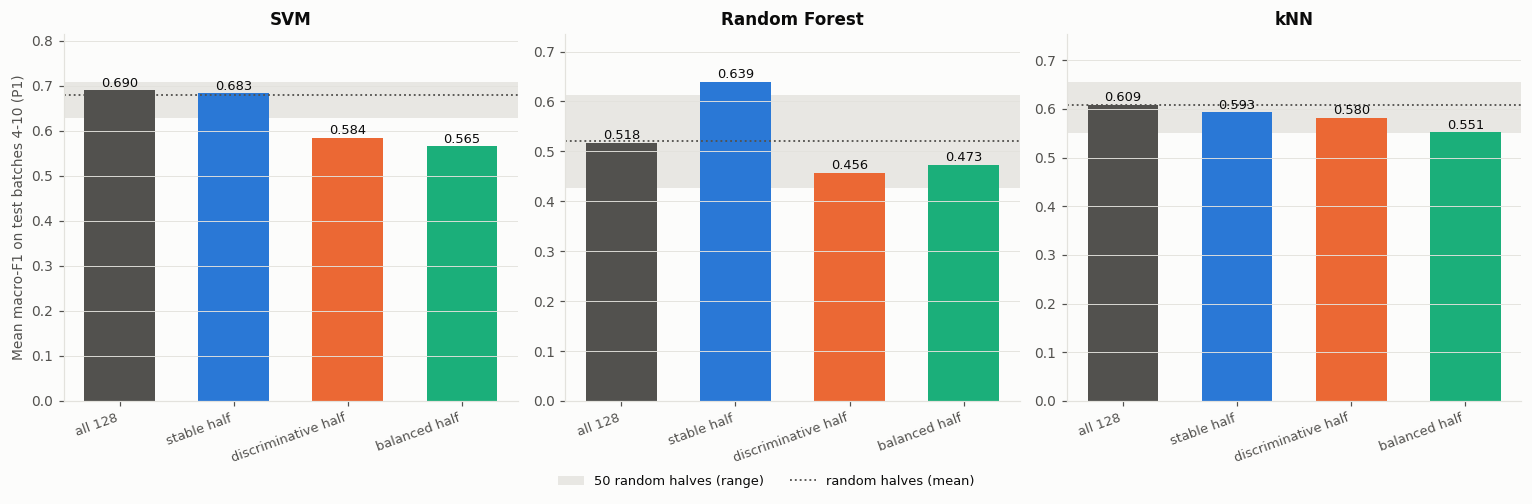

Sensors / types kept by the 'stable' rule (count of the 64 features):
{'S03': 8, 'S04': 8, 'S05': 2, 'S06': 5, 'S07': 6, 'S08': 5, 'S11': 6, 'S12': 6, 'S13': 3, 'S14': 5, 'S15': 5, 'S16': 5}
{'DR': 11, '|DR|': 4, 'EMA_inc_0.001': 10, 'EMA_inc_0.01': 3, 'EMA_inc_0.1': 2, 'EMA_dec_0.001': 12, 'EMA_dec_0.01': 12, 'EMA_dec_0.1': 10}


In [5]:
mm = sel.groupby(["model", "rule", "frac", "seed"]).macro_f1.mean().reset_index()
mm.to_csv(RES / "09_selection_summary_per_run.csv", index=False)
rows = []
for model in ["SVM", "Random Forest", "kNN"]:
    full = mm[(mm.model == model) & (mm.rule == "all")].macro_f1.iloc[0]
    for frac in [0.25, 0.5, 0.75]:
        rnd = mm[(mm.model == model) & (mm.rule == "random") & (mm.frac == frac)].macro_f1
        r = {"model": model, "fraction kept": frac, "all features": full, "random mean": rnd.mean(), "random 5-95%": f"{rnd.quantile(.05):.3f}-{rnd.quantile(.95):.3f}"}
        for rule in ["stable", "discriminative", "balanced"]:
            v = mm[(mm.model == model) & (mm.rule == rule) & (mm.frac == frac)].macro_f1.iloc[0]
            r[rule] = v; r[f"{rule} beats x% of random"] = float((rnd < v).mean() * 100)
        rows.append(r)
summary = pd.DataFrame(rows); summary.to_csv(RES / "09_selection_summary.csv", index=False)
pd.set_option("display.width", 250); display(summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=False)
for ax, model in zip(axes, ["SVM", "Random Forest", "kNN"]):
    s = summary[(summary.model == model) & (summary["fraction kept"] == 0.5)].iloc[0]
    rnd = mm[(mm.model == model) & (mm.rule == "random") & (mm.frac == 0.5)].macro_f1
    vals = [s["all features"], s["stable"], s["discriminative"], s["balanced"]]; names = ["all 128", "stable half", "discriminative half", "balanced half"]
    ax.axhspan(rnd.min(), rnd.max(), color=GRID, alpha=0.8, lw=0, label="50 random halves (range)"); ax.axhline(rnd.mean(), color=INK2, ls=":", lw=1.2, label="random halves (mean)")
    ax.bar(range(4), vals, color=[INK2, SERIES[0], SERIES[1], SERIES[2]], width=0.62)
    for i, v in enumerate(vals): ax.text(i, v + 0.008, f"{v:.3f}", ha="center", fontsize=8.5)
    ax.set_xticks(range(4)); ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8.5); ax.set_title(model); ax.set_ylim(0, max(max(vals), rnd.max()) * 1.15); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Mean macro-F1 on test batches 4-10 (P1)"); h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=2, frameon=False, fontsize=8.5, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(); fig.savefig(FIG / "36_feature_selection.png"); plt.show()

stable_idx = fs.sort_values(["drift", "feature"]).feature.to_numpy()[:64]
print("Sensors / types kept by the 'stable' rule (count of the 64 features):")
print(fs.loc[fs.feature.isin(stable_idx), "sensor"].value_counts().sort_index().to_dict()); print(fs.loc[fs.feature.isin(stable_idx), "type"].value_counts().reindex(FEATURE_TYPES).to_dict())

## 5. Key takeaways

All models are default-setting, scaling only, trained on batches 1-3 (protocol P1) and tested on batches 4-10. Feature scores and any selection use batches 1-3 only; permutation importance and the ablations are descriptive analyses of test-batch behaviour and were not used to choose anything.

1. **The most informative sensors are also the ones that drift most.** In the training batches the four sensors S01, S02, S09 and S10 separate the gases best (mean log10 F 2.9-3.0, against 1.5-2.5 for the others) but also drift most (median shift of each gas from batch 1 to batches 2-3: S10 2.73, S09 2.24, S01 1.77, S02 1.49 robust SDs, against 0.66-1.19 for the rest). These are the same sensors that stood out in notebook 01 (S01 falling to about 1/24 of its batch-1 response). Across all 128 features the correlation between discriminability and drift is +0.39.
2. **Used on their own, those four sensors are the worst later on.** Retraining the SVM on one sensor only (P1, macro-F1; all 128 features give 0.690): S08 0.586, S04 0.566 and S07 0.552 are best, whereas S01 0.319, S10 0.340, S02 0.344 and S09 0.345 are worst. What looked most useful in the training period does not transfer.
3. **Removing the most drift-prone sensor helps in P1.** Removing S01 raises the SVM from 0.690 to 0.723 (+0.033) and kNN from 0.609 to 0.648 (+0.039); removing any other single sensor changes the SVM by -0.015 to +0.003. Under rolling retraining (P3) the effect disappears (SVM 0.793 vs 0.797 without S01), so it is a fixed-training-set effect.
4. **Features are highly redundant.** Removing any single feature type changes the SVM's macro-F1 by only -0.035 (DR) to +0.001; no single type or family reaches the full set (best: DR alone 0.611; rising EMAs 0.619, steady-state 0.584, decaying EMAs 0.562). Permutation importance is therefore spread across many sensors (no sensor above a 0.07 drop in macro-F1 for the SVM). By family the SVM relies most on the rising EMAs (drop 0.301), then steady-state (0.199) and decaying EMAs (0.172); the Random Forest relies on all three about equally (0.094-0.138). The SVM's reliance moves with distance: DR matters more on far batches (0.224) than near ones (0.123), the reverse of EMA_inc_0.01 (0.249 near, 0.070 far); these near/far differences are noisy and differ between models.
5. **Choosing features by training discriminability hurts; choosing by stability helps some models.** With the pre-declared half of the features: SVM all 0.690, stable half 0.683, discriminative half 0.584, balanced half 0.565 (random halves: mean 0.678, 5-95% range 0.651-0.697; the discriminative and balanced rules beat 0% of the random halves). Random Forest: all 0.518, **stable half 0.639**, discriminative 0.456, balanced 0.473; the stable half beats all 50 random halves (mean 0.521). kNN: all 0.609, stable 0.593, discriminative 0.580, balanced 0.551. The stable half contains no feature of S01, S02, S09 or S10 and is dominated by decaying EMAs (34 of 64).
6. **Sensitivity of the selection result.** Keeping 25% of the features, the stable rule is worse than random halves for the SVM (0.550) and kNN (0.492) and better for the Random Forest (0.563, beats 96% of random subsets). Keeping 75%, it is neutral for the SVM (0.683), helps the Random Forest (0.588; beats all random subsets) and kNN (0.654, +0.045 over all features, beats all random subsets). The effect is therefore **model-dependent: strong for Random Forest, neutral for SVM, inconsistent for kNN**.
7. **What this means.** Drift is concentrated in a small, identifiable set of sensors, and the usual instinct (keep the most discriminative features) is exactly wrong for them. For tree-based models, dropping the drift-prone sensors is a cheap, interpretable and effective mitigation (Random Forest 0.518 to 0.639); it does not beat the default SVM (0.690), and the SVM does not need it. This also supports the slide-5 claim of an *interpretable* pipeline: the results can be explained sensor by sensor.
8. **Caveats.** Drift is estimated from only two near-term batch pairs (1-2 and 1-3) using per-gas medians, which are also affected by concentration differences; the F-statistic pools batches; Toluene has too few samples in batches 2-3 (5 and 0) to enter the drift estimate, although it does enter the F-statistic through batch 1 (74 samples), so the drift of the features that separate Toluene is not measured; selection was evaluated only under P1 (not rolling retraining); nine selection comparisons were made without multiple-testing correction, and the random-subset comparison is a null reference, not a formal test; permutation importance with correlated features is approximate; sensor ablations were read off test batches and are descriptive only.